In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) -- 
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [2]:
# 1. Silence C++ backend warnings (Must be before importing/using TF operations)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

try:
    import tensorflow as tf
except:
    !uv pip install tensorflow
    import tensorflow as tf

import logging

# 2. Silence Python level TensorFlow/ABSL warnings
tf.get_logger().setLevel(logging.ERROR)
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('absl').setLevel(logging.ERROR)

In [3]:
## -- keras library --
try:
    from scikeras.wrappers import KerasClassifier
except:
    !uv pip install scikeras
    from scikeras.wrappers import KerasClassifier

print()
# !pip show scikeras

Using Python 3.13.15 environment at: /usr
Resolved 19 packages in 549ms
Prepared 1 package in 26ms
Installed 1 package in 5ms
 + scikeras==0.13.0



In [4]:
!uv pip install ipywidgets
!uv pip install pygraphviz

!apt-get install -qq -y graphviz graphviz-dev && pip install -qq pydot

Using Python 3.13.15 environment at: /usr
Checked 1 package in 142ms
Using Python 3.13.15 environment at: /usr
Resolved 1 package in 183ms
Prepared 1 package in 190ms
Installed 1 package in 3ms
 + pygraphviz==2.0.3
Selecting previously unselected package at-spi2-common.
(Reading database ... 125659 files and directories currently installed.)
Preparing to unpack .../00-at-spi2-common_2.52.0-1build1_all.deb ...
Unpacking at-spi2-common (2.52.0-1build1) ...
Selecting previously unselected package libatk1.0-0t64:amd64.
Preparing to unpack .../01-libatk1.0-0t64_2.52.0-1build1_amd64.deb ...
Unpacking libatk1.0-0t64:amd64 (2.52.0-1build1) ...
Selecting previously unselected package libgtk2.0-common.
Preparing to unpack .../02-libgtk2.0-common_2.24.33-4ubuntu1.1_all.deb ...
Unpacking libgtk2.0-common (2.24.33-4ubuntu1.1) ...
Selecting previously unselected package libxcomposite1:amd64.
Preparing to unpack .../03-libxcomposite1_1%3a0.4.5-1build3_amd64.deb ...
Unpacking libxcomposite1:amd64 (1:0

In [5]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import shutil
import itertools
from tqdm import tqdm
from time import time, sleep

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, PredictionErrorDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, TargetEncoder as skTE

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

import warnings
# warnings.filterwarnings("ignore", message="Setting the random state for TF")
tf.get_logger().setLevel('ERROR')
warnings.simplefilter('ignore')

def seed_everything(seed: int):
    print(f"✓ Seed everything at {seed}")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
seed_everything(42)

✓ Seed everything at 42


In [6]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [7]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --

PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e9/"
    submission = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/"
    orig = pd.read_csv(ORIG_PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e9 | EV Purchase/_ev_purchase_data/"
    submission = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")

## =================================================================================

ID     = "id"
TARGET = 'Will_Buy_EV'

obj = train.select_dtypes(include=["object", "category"]).columns.tolist()

cat_cols  = [c for c in obj if c not in [TARGET, ID]]
num_cols  = [c for c in train.columns if c not in cat_cols+[TARGET, ID]]
base_cols = cat_cols + num_cols

train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET]  = orig[TARGET].map({'No': 0, 'Yes': 1})

FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

orig = orig[FEATURES+[TARGET]]
print("Total Features:", len(FEATURES))

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(num_cols)}")
print(f"Total Cats: {len(cat_cols)}")
print(f"Total base: {len(base_cols)}")

Total Features: 13
Train shape: (668665, 15)
Test shape: (286571, 14)
Orig shape: (10000, 14)

Total Nums: 7
Total Cats: 6
Total base: 13


In [8]:
for c in num_cols:
    orig[c] = orig[c].fillna(orig[c].median())

print(orig.isna().sum())

Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64


In [9]:
n_unique = train[base_cols].nunique().sort_values()
n_unique

Home_Charging_Possible             2
Subsidy_Available                  2
City_Type                          3
Gender                             3
Range_Anxiety_Level                3
Current_Car_Type                   4
Number_of_Cars_Owned               4
Environmental_Concern_Level        5
Charging_Stations_Near_Home       15
Charging_Stations_Near_Work       20
Age                               45
Daily_Commute_km                 805
Annual_Income_USD              13214
dtype: int64

In [10]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights

print("- Helper Functions Ready -")

- Helper Functions Ready -


In [11]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [12]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc="original_augmenting"):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


## FEATURE ENGINEERING

In [13]:
# ## -- Cyclic encoding --
# cyclic_cols = []
# cy_cols = ["Daily_Commute_km"]

# for col in tqdm(cy_cols):
#     for p in [12]:
#         n_s = f"{col}_sin_{p}"

#         train[n_s] = np.sin(2 * np.pi * train[col] / p).astype('float32')
#         test[n_s]  = np.sin(2 * np.pi * test[col] / p).astype('float32')
#         orig[n_s]  = np.sin(2 * np.pi * orig[col] / p).astype('float32')
#         cyclic_cols.append(n_s)

#         # n_c = f"{col}_cos_{p}"
#         # train[n_c] = np.cos(2 * np.pi * train[col] / p).astype('float32')
#         # test[n_c] = np.cos(2 * np.pi * test[col] / p).astype('float32')
#         # orig[n_c] = np.cos(2 * np.pi * orig[col] / p).astype('float32')
#         # cyclic_cols.append(n_c)

# # num_cols.extend(cyclic_cols)

# print(f"Cylcic Features created: {len(cyclic_cols)}")
# display(train[cyclic_cols].describe().T)

# train[cyclic_cols]

In [14]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Features before:", len(FEATURES))

combined = pd.concat([train, test, orig])
## ------------------------------------------------------------
## -- Duplicate Nums as Cats --
nums_to_cats = []
select_cols = [_ for _ in num_cols if train[_].nunique() > 500]
print("Converting nums to cats:", end="")
for c in select_cols:
    n = f"{c}_cat"
    print(n, end="... ")
    combined[n] = combined[c].factorize()[0]
    # combined[n] = combined[n].astype('category')
    nums_to_cats.append(n)
FEATURES = list(set(FEATURES + nums_to_cats))
## ------------------------------------------------------------
# ## -- Factorize all cat_cols --
# for c in cat_cols:
#     combined[c] = combined[c].factorize()[0]
#     # combined[c] = combined[c].astype('category')
# print("Label encoding complete!")
## ------------------------------------------------------------

train = combined.iloc[:len(train)]
test  = combined.iloc[len(train):len(train)+len(test)].drop(columns=[TARGET])
orig  = combined.iloc[-len(orig):]

del combined

_ = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(_))

print("\nTotal Features:", len(FEATURES))

# train

Features before: 13
Converting nums to cats:Annual_Income_USD_cat... Daily_Commute_km_cat... 
Total Features: 15


In [15]:
## -- Frequency encoding --
freq_cols = []
select_freq = [c for c in base_cols if train[c].nunique() > 2]

print(f"\nCreating frequencies... ", end="")
for col in select_freq:
    freq = pd.concat([train[col], test[col], orig[col]]).value_counts(dropna=False, normalize=True)
    n = f"{col}_freq"
    print(n+", ", end="")
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype("float32")
    freq_cols.append(n)

num_cols = list(set(num_cols + freq_cols))
FEATURES = list(set(FEATURES + freq_cols))

print(f"\n✓ Total frequency features: {len(freq_cols)}")

_ = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(_))

print("Total Features:", len(FEATURES))

# train


Creating frequencies... Gender_freq, City_Type_freq, Current_Car_Type_freq, Range_Anxiety_Level_freq, Age_freq, Annual_Income_USD_freq, Daily_Commute_km_freq, Number_of_Cars_Owned_freq, Charging_Stations_Near_Home_freq, Charging_Stations_Near_Work_freq, Environmental_Concern_Level_freq, 
✓ Total frequency features: 11
Total Features: 26


In [16]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
combined = pd.concat([train, test, orig])

digit_cols = []
cols_select = ["Annual_Income_USD", "Daily_Commute_km"] # 

for col in sorted(cols_select):
    scaled = np.rint(combined[col] * 10**4).astype("int64")
    for k in range(-4, 4):
        dig_col = f"{col}_digit{k}"
        combined[dig_col] = (scaled // 10**(k + 4) % 10).astype('int8')
        digit_cols.append(dig_col)

train = combined.iloc[:len(train)][list(set(base_cols + FEATURES + digit_cols)) + [TARGET]]
test = combined.iloc[len(train):len(train)+len(test)][list(set(base_cols + FEATURES + digit_cols))]
orig = combined.iloc[-len(orig):][list(set(base_cols + FEATURES + digit_cols)) + [TARGET]]

# Check nunique, and find which ones are < 2
unique_counts = train[digit_cols].nunique()
drop_cols = unique_counts[unique_counts < 2].index.tolist()

# update digit cols for keep
digit_cols = [i for i in set(digit_cols) if i not in set(drop_cols)]

# drop constant features
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)
orig  = orig.drop(columns=drop_cols)

# num_cols = list(set(num_cols + digit_cols))
# cat_cols = list(set(cat_cols + digit_cols))

print(f"Total digit features: {len(digit_cols)}\n")
del combined

_ = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(_))

print("Total Features:", len(FEATURES))

# train

Total digit features: 7

Total Features: 33


In [17]:
INTER = []

combo_2_list = list(itertools.combinations(cat_cols+digit_cols, 2)) #digit_cols + cat_cols
for c1, c2 in tqdm(combo_2_list, desc='Pairwise'):
    n_col = f"Bi_{c1}_{c2}"
    train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str)).factorize()[0]
    test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str)).factorize()[0]
    orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str)).factorize()[0]
    INTER.append(n_col)

# combo_3_list = list(itertools.combinations(digit_cols, 3))
# for c1, c2, c3 in tqdm(combo_3_list, desc='Triplewise'):
#     n_col = f"Tri_{c1}_{c2}_{c3}"
#     train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)).factorize()[0]
#     test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)).factorize()[0]
#     orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + orig[c3].astype(str)).factorize()[0]
#     INTER.append(n_col)

# combo_2_list2 = list(itertools.combinations(cat_cols, 2))
# for c1, c2 in tqdm(combo_2_list2, desc='Pairwise'):
#     n_col = f"Bi_{c1}_{c2}"
#     train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str)).factorize()[0]
#     test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str)).factorize()[0]
#     orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str)).factorize()[0]
#     INTER.append(n_col)

# combo_3_list2 = list(itertools.combinations(cat_cols, 3))
# for c1, c2, c3 in tqdm(combo_3_list2, desc='Triplewise'):
#     n_col = f"Tri_{c1}_{c2}_{c3}"
#     train[n_col] = (train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)).factorize()[0]
#     test[n_col]  = (test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)).factorize()[0]
#     orig[n_col]  = (orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + orig[c3].astype(str)).factorize()[0]
#     INTER.append(n_col)

# combo_2_1toMany = list(itertools.product(cat_cols, digit_cols))
# for c1, c2 in tqdm(combo_2_1toMany, desc='One-to-Many'):
#     n_col = f"Bi2_{c1}_{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")
gc.collect()

Pairwise: 100%|██████████| 78/78 [00:36<00:00,  2.13it/s]

Total Interaction Features: 78


30

In [18]:
def feat_eng(df1, trn=True):
    df = df1.copy()
    # Arithmetic interaction
    # df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1)).astype('float32')

    df['Income_//_10_cat'] = (df['Annual_Income_USD'] // 10).astype('float32')
    df['Income_//_100_cat'] = (df['Annual_Income_USD'] // 100).astype('float32')
    # df['Income_//_1000_cat'] = (df['Annual_Income_USD'] // 1000).astype('float32')
    # # df['gt_179k_lock'] = (df['Annual_Income_USD'] >= 179_000).astype('int8')

    # log_cols = []
    # for col in ['Annual_Income_USD', 'Daily_Commute_km']:
    #     log_name = f"_log_{col}"
    #     df[log_name] = np.log(df[col])
    #     log_cols.append(log_name)

    # nm_cols = ['_Daily_Commute_km_/_Age'] #+ log_cols
    ct_cols = ['Income_//_10_cat', 'Income_//_100_cat'] # 'Income_//_1000_cat' 

    if trn:
        return df, ct_cols #, nm_cols
    else:
        return df

# train, nm_cols, ct_cols = feat_eng(train)
train, ct_cols = feat_eng(train)
test = feat_eng(test, trn=False)
orig = feat_eng(orig, trn=False)

# num_cols = list(set(num_cols + nm_cols)) 
# cat_cols = list(set(cat_cols + ct_cols))

_ = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(_))

print("Total Features:", len(FEATURES))

# train

Total Features: 113


In [19]:
_ = [c for c in train.columns if c not in [ID, TARGET]]
FEATURES = list(set(_))

print("Total Features:", len(FEATURES))

train

Total Features: 113


,Range_Anxiety_Level_freq,Annual_Income_USD_digit2,Environmental_Concern_Level_freq,Range_Anxiety_Level,Home_Charging_Possible,Daily_Commute_km_freq,Daily_Commute_km_digit0,Number_of_Cars_Owned_freq,Age,Annual_Income_USD_digit1,Current_Car_Type,City_Type_freq,Annual_Income_USD_digit3,Daily_Commute_km_cat,Annual_Income_USD_digit0,Charging_Stations_Near_Home_freq,Annual_Income_USD_freq,Number_of_Cars_Owned,Daily_Commute_km,Current_Car_Type_freq,Daily_Commute_km_digit1,City_Type,Charging_Stations_Near_Work_freq,Subsidy_Available,Charging_Stations_Near_Home,Daily_Commute_km_digit-1,Annual_Income_USD_cat,Gender_freq,Charging_Stations_Near_Work,Age_freq,Annual_Income_USD,Gender,Environmental_Concern_Level,Will_Buy_EV,Bi_Gender_City_Type,Bi_Gender_Current_Car_Type,Bi_Gender_Home_Charging_Possible,Bi_Gender_Subsidy_Available,Bi_Gender_Range_Anxiety_Level,Bi_Gender_Annual_Income_USD_digit3,Bi_Gender_Annual_Income_USD_digit2,Bi_Gender_Daily_Commute_km_digit1,Bi_Gender_Daily_Commute_km_digit-1,Bi_Gender_Daily_Commute_km_digit0,Bi_Gender_Annual_Income_USD_digit0,Bi_Gender_Annual_Income_USD_digit1,Bi_City_Type_Current_Car_Type,Bi_City_Type_Home_Charging_Possible,Bi_City_Type_Subsidy_Available,Bi_City_Type_Range_Anxiety_Level,Bi_City_Type_Annual_Income_USD_digit3,Bi_City_Type_Annual_Income_USD_digit2,Bi_City_Type_Daily_Commute_km_digit1,Bi_City_Type_Daily_Commute_km_digit-1,Bi_City_Type_Daily_Commute_km_digit0,Bi_City_Type_Annual_Income_USD_digit0,Bi_City_Type_Annual_Income_USD_digit1,Bi_Current_Car_Type_Home_Charging_Possible,Bi_Current_Car_Type_Subsidy_Available,Bi_Current_Car_Type_Range_Anxiety_Level,Bi_Current_Car_Type_Annual_Income_USD_digit3,Bi_Current_Car_Type_Annual_Income_USD_digit2,Bi_Current_Car_Type_Daily_Commute_km_digit1,Bi_Current_Car_Type_Daily_Commute_km_digit-1,Bi_Current_Car_Type_Daily_Commute_km_digit0,Bi_Current_Car_Type_Annual_Income_USD_digit0,Bi_Current_Car_Type_Annual_Income_USD_digit1,Bi_Home_Charging_Possible_Subsidy_Available,Bi_Home_Charging_Possible_Range_Anxiety_Level,Bi_Home_Charging_Possible_Annual_Income_USD_digit3,Bi_Home_Charging_Possible_Annual_Income_USD_digit2,Bi_Home_Charging_Possible_Daily_Commute_km_digit1,Bi_Home_Charging_Possible_Daily_Commute_km_digit-1,Bi_Home_Charging_Possible_Daily_Commute_km_digit0,Bi_Home_Charging_Possible_Annual_Income_USD_digit0,Bi_Home_Charging_Possible_Annual_Income_USD_digit1,Bi_Subsidy_Available_Range_Anxiety_Level,Bi_Subsidy_Available_Annual_Income_USD_digit3,Bi_Subsidy_Available_Annual_Income_USD_digit2,Bi_Subsidy_Available_Daily_Commute_km_digit1,Bi_Subsidy_Available_Daily_Commute_km_digit-1,Bi_Subsidy_Available_Daily_Commute_km_digit0,Bi_Subsidy_Available_Annual_Income_USD_digit0,Bi_Subsidy_Available_Annual_Income_USD_digit1,Bi_Range_Anxiety_Level_Annual_Income_USD_digit3,Bi_Range_Anxiety_Level_Annual_Income_USD_digit2,Bi_Range_Anxiety_Level_Daily_Commute_km_digit1,Bi_Range_Anxiety_Level_Daily_Commute_km_digit-1,Bi_Range_Anxiety_Level_Daily_Commute_km_digit0,Bi_Range_Anxiety_Level_Annual_Income_USD_digit0,Bi_Range_Anxiety_Level_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit2,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit-1,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit1,Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit-1_Annual_Inco

# ML TRAINING

In [20]:
## -- SAMPLE MLP VIEWER --
n_features = len(FEATURES)
units = [512, 256, 64]

seq_layers = []
seq_layers.append(tf.keras.Input(shape=(n_features,)))
seq_layers.append(tf.keras.layers.BatchNormalization())

for i in range(len(units)):
    if i < (len(units) - 1):
        d = max(64, units[0] // (2**i))
    else:
        d = 64

    seq_layers.append(tf.keras.layers.Dense(units=d, activation='relu'))
    seq_layers.append(tf.keras.layers.BatchNormalization())
    seq_layers.append(tf.keras.layers.Dropout(0.1))
    # Increase dropout as layers get deeper/smaller -> dropout_rate+(i * 0.05)

# Final output layer
seq_layers.append(tf.keras.layers.Dense(1, activation='sigmoid'))

# 3. Create the Sequential model for the "head"
model = tf.keras.Sequential(seq_layers)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 113)            │           452 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        58,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,989 (820.27 KB)

 Trainable params: 208,099 (812.89 KB)

 Non-trainable params: 1,890 (7.38 KB)

In [21]:
def keras_mlp(meta, lr, units, act, drop):
    print(f"⚡️ Keras MLP Build")
    # SciKeras passes feature count after ColumnTransformer transformations in meta
    n_features = meta["n_features_in_"]
    seq_layers = []

    # 1. Add Input and the critical initial BatchNormalization layer
    seq_layers.append(tf.keras.Input(shape=(n_features,)))
    seq_layers.append(tf.keras.layers.BatchNormalization())

    # 2. Loop explicitly over your units list to match the architecture
    for u in units:
        seq_layers.append(tf.keras.layers.Dense(units=u, activation=act))
        seq_layers.append(tf.keras.layers.BatchNormalization())
        seq_layers.append(tf.keras.layers.Dropout(drop))

    # 3. Final output layer
    seq_layers.append(tf.keras.layers.Dense(1, activation='sigmoid'))

    # Compile model
    model = tf.keras.Sequential(seq_layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

print("⚙️ Keras MLP model ⚙️")


⚙️ Keras MLP model ⚙️


In [22]:
def keras_seq(meta, lr, units, act, drop):
    print(f"⚡️ Keras SEQUENTIAL Build")
    # SciKeras passes feature count after ColumnTransformer transformations in meta
    n_features = meta["n_features_in_"]

    model = tf.keras.Sequential([
        tf.keras.Input(shape=(n_features,)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(units[0], activation=act),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(drop),
        tf.keras.layers.Dense(units[1], activation=act),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(drop),
        tf.keras.layers.Dense(units[2], activation=act),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(drop),
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

print("⚙️ Keras SEQUENTIAL model ⚙️")

⚙️ Keras SEQUENTIAL model ⚙️


In [23]:
if "digit_cols" in globals():
    print("✓ digit_cols available!")
else:
    print("𝗫 digit_cols unavailable!")

✓ digit_cols available!


In [24]:
## -- Define TranerCV --

class TrainerCV:
    def __init__(
        self,
        model_mlp, # function -> tf.keras.Model
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        kfold,
        learning_rate: float=0.01,
        layer_units: list=[256, 128, 64],
        drop_rate: float=0.2,
        batch_size: int=32,
        epochs: int=10,
        patience: int=3,
        activation: str='relu',
        eval_metric: str='auc',
        use_orig: bool=False,
        use_te: bool=False,
        **kwargs
    ):
        self.model_mlp = model_mlp
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features.copy()
        self.target = target
        self.kfold = kfold
        self.learning_rate = learning_rate
        self.units = layer_units
        self.drop_rate = drop_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.activation = activation
        self.eval_metric = eval_metric
        self.use_orig = use_orig
        self.use_te = use_te

        self.result = None

        # Storage
        self.oof_preds   = np.zeros(len(train_df))
        self.test_preds  = np.zeros(len(test_df))
        self.fold_scores = []

    def _prepare_fold_data(self, X, y, X_val=None, y_valid=None):
        # This helper can be extended if you want to apply masks or augmentation.
        return X, y

    def fit(self):
        print(f"\n===== Starting CV: {self.model_name} | =====")
        t0 = time()

        self.oof_preds  = np.zeros(len(self.train_df))
        self.test_preds = np.zeros(len(self.test_df))
        self.oof_scores = []
        self.fold_histories = []

        # Handle optional original table aggregations
        if self.use_orig and "original_TE" in globals():
            feats = self.features.copy()
            aggs_ = ["mean"] #, "std"
            X_tr, orig_cols = original_TE(
                orig, self.train_df, target=self.target, features=base_cols, aggs=aggs_, fill_nan=True
            )
            x_test, _ = original_TE(
                orig, self.test_df, target=self.target, features=base_cols, aggs=aggs_, fill_nan=True
            )
            feats.extend(orig_cols)
            X = X_tr[feats]
            X_ts = x_test[feats]
            y = X_tr[self.target].astype("int8")
        else:
            X = self.train_df[self.features]
            X_ts = self.test_df[self.features]
            y = self.train_df[self.target].astype("int8")

        strategy = tf.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print('⚙️ Number of devices: {}'.format(strategy.num_replicas_in_sync))

        for idx, (train_idx, val_idx) in enumerate(self.kfold.split(X, y), 1):
            print(f"\n+++++ FOLD {idx}/{self.kfold.n_splits}")

            X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
            X_test = X_ts.copy()

            # -- Callbacks --
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_auc" if self.eval_metric == "auc" else "val_loss",
                    patience=self.patience,
                    mode="max" if self.eval_metric == "auc" else "min",
                    restore_best_weights=True,
                ),
                tf.keras.callbacks.ModelCheckpoint( # -> save model
                    filepath=f"{CHECKPOINT}best_model.model.keras",
                    monitor="val_auc" if self.eval_metric == "auc" else "val_loss",
                    mode="max" if self.eval_metric == "auc" else "min",
                    save_best_only=True,
                    # verbose=1
                ),
                # tf.keras.callbacks.ModelCheckpoint( # -> save weights
                #     filepath=f"{CHECKPOINT}best_model.weights.h5",
                #     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                #     save_best_only=True,
                #     save_weights_only=True,
                # ),
                # tf.keras.callbacks.ReduceLROnPlateau(
                #     monitor='val_auc' if self.eval_metric == 'auc' else 'val_loss',
                #     factor=0.5,
                #     patience=5,
                #     min_lr=1e-6,
                #     verbose=1
                # ),
            ]

            # if self.use_orig:
            #     X_train = pd.concat([X_train, orig[features]]).fillna('unknown').reset_index(drop=True).copy()
            #     y_train = pd.concat([y_train, orig[target]]).reset_index(drop=True).copy()
            #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

            ## -- TE Opt1. -> Using CUSTOM --
            if self.use_te:
                te_cols = ct_cols + nums_to_cats #+ INTER 
                print(f"⧗ Target encoding ({len(te_cols)}) features", end=" | ")
                TE = TargetEncoder(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
                X_train = TE.fit_transform(X_train, y_train)
                X_valid = TE.transform(X_valid)
                X_test  = TE.transform(X_test)
            else:
                te_cols = []

            te_features = [c for c in X_train.columns if c.startswith(('TE_', 'oTE_'))]

            ## ------------------------------------------------------------------------
            # # ---- Scaling ----  
            # scaler = StandardScaler().set_output(transform="pandas")
            # X_train = scaler.fit_transform(X_train, y_train)
            # X_valid = scaler.transform(X_valid)
            # X_test  = scaler.transform(X_test)

            # impute_num_cols = X_train.columns[X_train[X_train.columns].isna().any()].tolist()
            # if impute_num_cols:
            #     imputer = SimpleImputer()
            #     X_train.loc[:, impute_num_cols] = imputer.fit_transform(X_train[impute_num_cols])
            #     X_valid.loc[:, impute_num_cols] = imputer.transform(X_valid[impute_num_cols])
            #     X_test.loc[:, impute_num_cols]  = imputer.transform(X_test[impute_num_cols])
            
            # #     # estimator = HistGradientBoostingRegressor(random_state=0)
            # imputer = IterativeImputer(tol=1e-3, n_nearest_features=10, random_state=0)
            # X_train = imputer.fit_transform(X_train, y_train)
            # X_valid = imputer.transform(X_valid)
            # X_test  = imputer.transform(X_test)

            ## -- Define encoders --
            scaler_enc  = StandardScaler()
            ohe_enc     = OneHotEncoder(handle_unknown="ignore", sparse_output=True, drop='if_binary')
            num_imputer = IterativeImputer(max_iter=50, tol=1e-3, add_indicator=True, random_state=9)
            cat_imputer = SimpleImputer(strategy="most_frequent", add_indicator=True)
            ## ------------------------------------------------------------------------
            # num_cols = [c for c in X_train.columns if c not in one_hot_cats]

            all_cats = list(set(cat_cols + te_features)) # + digit_cols
            # ohe_cols  = [c for c in X_train.columns if c.startswith('ohe_')]
            only_nums = [c for c in X_train.columns if c not in all_cats]
            full_nums = list(set(only_nums+orig_cols)) if self.use_orig else list(set(only_nums))

            num_proc = make_pipeline(scaler_enc)
            cat_proc = make_pipeline(ohe_enc)

            preprocessor = make_column_transformer(
                # (num_proc, full_nums),
                (cat_proc, cat_cols+digit_cols if "digit_cols" in globals() else cat_cols), #
                remainder='passthrough', n_jobs=-1,
            )

            # -- Build model --
            print(f"🟢 Training model graph *** Layers[Units] -> {self.units}")
            # with strategy.scope():
            keras_clf = KerasClassifier(
                keras_mlp if self.model_mlp else keras_seq,
                # model__shape=X_train.shape[1:],
                lr=self.learning_rate,
                units=self.units,
                act=self.activation,
                drop=self.drop_rate,
                # ---------------------------------------------------------
                # # optimizer=tf.keras.optimizers.RMSprop(self.learning_rate),
                # optimizer=tf.keras.optimizers.Adam(self.learning_rate), # , weight_decay=None
                # loss="binary_crossentropy",
                # metrics=[tf.keras.metrics.AUC(name=self.eval_metric)],
                # ---------------------------------------------------------
                epochs=self.epochs,
                batch_size=GLOBAL_BATCH_SIZE,
                # fit__batch_size=GLOBAL_BATCH_SIZE,
                # validation_batch_size=10000,
                # predict__batch_size=10000,
                random_state=42,
                callbacks=callbacks,
                run_eagerly=False,
                shuffle=True,
                verbose=1,
                # class_weight=get_weights(y_train, y_train),
            )
            # sample_weight=get_weights(y_train, y_train) 

            print(f"base_train: {X_train.shape}, base_valid: {X_valid.shape} | apply_TE: {self.use_te} +++++")
            print()
            if idx == 1:
                display(X_train.head())

            # ------------------------------------------------------------------------------
            X_train_trans = preprocessor.fit_transform(X_train, y_train)
            X_valid_trans = preprocessor.transform(X_valid)
            X_test_trans = preprocessor.transform(X_test)

            print(f"input_train: {X_train_trans.shape}, input_valid: {X_valid_trans.shape} +++++")

            keras_clf.fit(X_train_trans, y_train, validation_data=(X_valid_trans, y_valid))
            self.fold_histories.append(keras_clf.history_)
            # ------------------------------------------------------------------------------
            # _process = preprocessor.fit(X_train, y_train)
            # X_valid_trans = _process.transform(X_valid)
            # X_test_trans = _process.transform(X_test)
            
            # keras_clf = make_pipeline(preprocessor, keras_clf, verbose=True)
            # keras_clf.fit(X_train, y_train, kerasclassifier__validation_data=(X_valid_trans, y_valid))
            # self.fold_histories.append(keras_clf.named_steps['kerasclassifier'].history_)
            
            # feature_names = keras_clf.named_steps['columntransformer'].get_feature_names_out()
            # print(f"⚡️ Total expanded features: {len(feature_names)}")
            # ------------------------------------------------------------------------------

            ## -- Make predictions --
            _val = keras_clf.predict_proba(X_valid_trans)[:, 1]
            # _val = keras_clf.named_steps['kerasclassifier'].predict_proba(X_valid_trans)[:, 1]
            self.oof_preds[val_idx] = _val

            fold_auc = roc_auc_score(y_valid, _val)
            self.oof_scores.append(fold_auc)

            _tst = keras_clf.predict_proba(X_test_trans)[:, 1]
            # _tst = keras_clf.named_steps['kerasclassifier'].predict_proba(X_test_trans)[:, 1]
            self.test_preds += _tst / self.kfold.n_splits

            print(f"{CFG['YELLOW']} • Fold {idx} AUC: {fold_auc:.6f}{CFG['RESET']}")

        # Print metrics
        print('\n'+'-'*50)
        print(f"{self.kfold.n_splits}-FOLD CV: {self.model_name} | shape: {X_train_trans.shape}")
        print('-'*50)
        for i, s in enumerate(self.oof_scores, 1):
            print(f" • Fold {i} AUC: {s:.6f}")

        oof_AUC = np.round(roc_auc_score(y, self.oof_preds), 6)
        avg_AUC = np.round(np.mean(self.oof_scores), 6)
        std_AUC = np.round(np.std(self.oof_scores), 6)

        print("-------------------------------------------------|")
        print(f"Overall score: {oof_AUC}")
        print(f"Average score: {avg_AUC} ± {std_AUC}")
        print("-------------------------------------------------|")
        print(f"{(time()-t0)/60:.2f} mins\n")

        return {
            'oof_preds': self.oof_preds,
            'test_preds': self.test_preds,
            'fold_score': self.oof_scores,
            'avg_score': avg_AUC,
            'oof_score': oof_AUC,
            'val_data': [X_valid, y_valid],
            'history': self.fold_histories,
        }

print("⚙️ Keras trainer ready ⚙️")

⚙️ Keras trainer ready ⚙️


In [25]:
all_predictions = {}

FOLDS = 10
USE_FULL_TRAIN = True

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

x_sample, x_sample2 = train_test_split(train, train_size=150_000, stratify=train[TARGET], random_state=0)
train_X = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

train_X

,Range_Anxiety_Level_freq,Annual_Income_USD_digit2,Environmental_Concern_Level_freq,Range_Anxiety_Level,Home_Charging_Possible,Daily_Commute_km_freq,Daily_Commute_km_digit0,Number_of_Cars_Owned_freq,Age,Annual_Income_USD_digit1,Current_Car_Type,City_Type_freq,Annual_Income_USD_digit3,Daily_Commute_km_cat,Annual_Income_USD_digit0,Charging_Stations_Near_Home_freq,Annual_Income_USD_freq,Number_of_Cars_Owned,Daily_Commute_km,Current_Car_Type_freq,Daily_Commute_km_digit1,City_Type,Charging_Stations_Near_Work_freq,Subsidy_Available,Charging_Stations_Near_Home,Daily_Commute_km_digit-1,Annual_Income_USD_cat,Gender_freq,Charging_Stations_Near_Work,Age_freq,Annual_Income_USD,Gender,Environmental_Concern_Level,Will_Buy_EV,Bi_Gender_City_Type,Bi_Gender_Current_Car_Type,Bi_Gender_Home_Charging_Possible,Bi_Gender_Subsidy_Available,Bi_Gender_Range_Anxiety_Level,Bi_Gender_Annual_Income_USD_digit3,Bi_Gender_Annual_Income_USD_digit2,Bi_Gender_Daily_Commute_km_digit1,Bi_Gender_Daily_Commute_km_digit-1,Bi_Gender_Daily_Commute_km_digit0,Bi_Gender_Annual_Income_USD_digit0,Bi_Gender_Annual_Income_USD_digit1,Bi_City_Type_Current_Car_Type,Bi_City_Type_Home_Charging_Possible,Bi_City_Type_Subsidy_Available,Bi_City_Type_Range_Anxiety_Level,Bi_City_Type_Annual_Income_USD_digit3,Bi_City_Type_Annual_Income_USD_digit2,Bi_City_Type_Daily_Commute_km_digit1,Bi_City_Type_Daily_Commute_km_digit-1,Bi_City_Type_Daily_Commute_km_digit0,Bi_City_Type_Annual_Income_USD_digit0,Bi_City_Type_Annual_Income_USD_digit1,Bi_Current_Car_Type_Home_Charging_Possible,Bi_Current_Car_Type_Subsidy_Available,Bi_Current_Car_Type_Range_Anxiety_Level,Bi_Current_Car_Type_Annual_Income_USD_digit3,Bi_Current_Car_Type_Annual_Income_USD_digit2,Bi_Current_Car_Type_Daily_Commute_km_digit1,Bi_Current_Car_Type_Daily_Commute_km_digit-1,Bi_Current_Car_Type_Daily_Commute_km_digit0,Bi_Current_Car_Type_Annual_Income_USD_digit0,Bi_Current_Car_Type_Annual_Income_USD_digit1,Bi_Home_Charging_Possible_Subsidy_Available,Bi_Home_Charging_Possible_Range_Anxiety_Level,Bi_Home_Charging_Possible_Annual_Income_USD_digit3,Bi_Home_Charging_Possible_Annual_Income_USD_digit2,Bi_Home_Charging_Possible_Daily_Commute_km_digit1,Bi_Home_Charging_Possible_Daily_Commute_km_digit-1,Bi_Home_Charging_Possible_Daily_Commute_km_digit0,Bi_Home_Charging_Possible_Annual_Income_USD_digit0,Bi_Home_Charging_Possible_Annual_Income_USD_digit1,Bi_Subsidy_Available_Range_Anxiety_Level,Bi_Subsidy_Available_Annual_Income_USD_digit3,Bi_Subsidy_Available_Annual_Income_USD_digit2,Bi_Subsidy_Available_Daily_Commute_km_digit1,Bi_Subsidy_Available_Daily_Commute_km_digit-1,Bi_Subsidy_Available_Daily_Commute_km_digit0,Bi_Subsidy_Available_Annual_Income_USD_digit0,Bi_Subsidy_Available_Annual_Income_USD_digit1,Bi_Range_Anxiety_Level_Annual_Income_USD_digit3,Bi_Range_Anxiety_Level_Annual_Income_USD_digit2,Bi_Range_Anxiety_Level_Daily_Commute_km_digit1,Bi_Range_Anxiety_Level_Daily_Commute_km_digit-1,Bi_Range_Anxiety_Level_Daily_Commute_km_digit0,Bi_Range_Anxiety_Level_Annual_Income_USD_digit0,Bi_Range_Anxiety_Level_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit2,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit-1,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit1,Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit-1_Annual_Inco

In [26]:
!rm -r /kaggle/working

rm: cannot remove '/kaggle/working': Device or resource busy


In [27]:
# dir(sdm)

In [28]:
# try:
#     import sdm
# except:
#     !pip install -q sdm
#     import sdm

# t = False

# x_1, x_2 = train_test_split(train[base_cols], train_size=100, stratify=train[TARGET], random_state=0)
# xs_1, xs_2 = train_test_split(test[base_cols], train_size=100, random_state=0)
# _X = train.copy() if t else x_1.reset_index(drop=True)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # A lossless, fully tensorized representation of the raw data on GPU:
# table = sdm.TableTensor.from_pandas(
#     df=_X,
#     stypes=sdm.infer_stypes(df, overrides={TARGET: "categorical"}),
#     device=device,
# )

# # Access to a variety of pre-trained structured data models:
# model = sdm.models.TabICLv2(device=device)

# # Default in-context learning forward pass:
# model(
#     # x_context=table[:300].drop_columns(TARGET),
#     # y_context=table[:300, "target"],
#     # x_query=table[300:].drop_columns("target"),
#     # num_estimators=8,

#     x_context=_X.drop_columns(TARGET),
#     y_context=_X[TARGET],
#     x_query=xs_1.drop_columns(TARGET),
#     num_estimators=2,
# )

# # Fit + Predict forward pass via key/value caching for fast inference:
# model.fit(
#     x=_X.drop_columns(TARGET),
#     y=_X[TARGET],
#     num_estimators=2,
# )
# preds = model.predict(xs_1)
# print(preds)
# # model.clear()

In [29]:
# try:
#     import sdm
# except:
#     !pip install -q sdm
#     import sdm

# # f = 3
# # skf = StratifiedKFold(n_splits=f, shuffle=True, random_state=42)
# t = False

# x_1, x_2 = train_test_split(train[base_cols], train_size=100, stratify=train[TARGET], random_state=0)
# xs_1, xs_2 = train_test_split(test[base_cols], train_size=100, random_state=0)
# _X = train.copy() if t else x_1.reset_index(drop=True)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # table = sdm.TableTensor.from_pandas(
# #     df=_X,
# #     stypes=sdm.infer_stypes(_X, overrides={TARGET: "categorical"}),
# #     device=device,
# # )

# # Access to a variety of pre-trained structured data models:
# model = sdm.models.TabICLv2(device=device)

# model = sdm.models.KumoTabular(task="classification", device=device)

# with torch.amp.autocast(
#     device.type,
#     dtype=torch.float16,
#     enabled=device.type == "cuda",
# ):
#     probs = model(
#         x_context=_X.drop_columns(TARGET),
#         y_context=_X[TARGET],
#         x_query=xs_1.drop_columns(TARGET),
#         num_estimators=2,
#     )

# print(probs)

In [30]:
CHECKPOINT = "checkpoints/"
shutil.rmtree(CHECKPOINT, ignore_errors=True)
os.makedirs(CHECKPOINT, exist_ok=True)

LR          = 0.001
EPOCHS      = 50
PATIENCE    = 5
BATCH_SIZE  = 128
DROP_RATE   = 0.5 ###
LAYER_UNITS = [512, 256, 64]

BUILD_MLP   = True
ACTIVATION  = "gelu"
scores = {}

MODEL_ = f"sciKeras{train_X.shape[1]}_" #+ str(LAYER_UNITS) + "_drop" + str(DROP_RATE )

# for model_type in [True, False]:
#     MODEL_ = f"sciKeras{train_X.shape[1]}_mlp_" + str(model_type)
trainer = TrainerCV(
    model_mlp     = BUILD_MLP,
    model_name    = MODEL_,
    train_df      = train_X,
    test_df       = test,
    features      = FEATURES,
    target        = TARGET,
    kfold         = skf,
    learning_rate = LR,
    layer_units   = LAYER_UNITS,
    batch_size    = BATCH_SIZE,
    epochs        = EPOCHS,
    patience      = PATIENCE,
    drop_rate     = DROP_RATE,
    activation    = ACTIVATION,
    eval_metric   = "auc",
    use_orig      = True,
    use_te        = True,
)
result = trainer.fit()

#     scores[MODEL_] = result['avg_score']


===== Starting CV: sciKeras114_ | =====


original_augmenting: 100%|██████████| 13/13 [00:01<00:00,  7.61it/s]


⚙️ Number of devices: 1

+++++ FOLD 1/10
⧗ Target encoding (4) features | 🟢 Training model graph *** Layers[Units] -> [512, 256, 64]
base_train: (601798, 126), base_valid: (66867, 126) | apply_TE: True +++++



,Environmental_Concern_Level_freq,Bi_City_Type_Annual_Income_USD_digit1,Daily_Commute_km_digit0,Daily_Commute_km_freq,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit0,Bi_Range_Anxiety_Level_Annual_Income_USD_digit2,Bi_City_Type_Subsidy_Available,Bi_Current_Car_Type_Annual_Income_USD_digit2,Bi_Current_Car_Type_Range_Anxiety_Level,Bi_City_Type_Daily_Commute_km_digit-1,Annual_Income_USD_freq,Bi_City_Type_Range_Anxiety_Level,Bi_Range_Anxiety_Level_Daily_Commute_km_digit1,Bi_Gender_Home_Charging_Possible,Bi_Gender_Current_Car_Type,Charging_Stations_Near_Work_freq,Bi_City_Type_Home_Charging_Possible,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit0_Annual_Income_USD_digit1,Bi_Home_Charging_Possible_Daily_Commute_km_digit1,Bi_Current_Car_Type_Daily_Commute_km_digit1,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit0,Daily_Commute_km_digit-1,Bi_Current_Car_Type_Home_Charging_Possible,Bi_Range_Anxiety_Level_Annual_Income_USD_digit3,Age_freq,Bi_Gender_Range_Anxiety_Level,Bi_Home_Charging_Possible_Annual_Income_USD_digit3,Gender,Bi_Gender_City_Type,Environmental_Concern_Level,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit1,Annual_Income_USD_digit2,Bi_Home_Charging_Possible_Range_Anxiety_Level,Bi_City_Type_Current_Car_Type,Home_Charging_Possible,Annual_Income_USD_digit1,Bi_Subsidy_Available_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit2,Bi_Home_Charging_Possible_Daily_Commute_km_digit0,Bi_Home_Charging_Possible_Subsidy_Available,Bi_Gender_Daily_Commute_km_digit0,Annual_Income_USD_digit0,Number_of_Cars_Owned,Bi_Subsidy_Available_Annual_Income_USD_digit2,City_Type,Bi_City_Type_Annual_Income_USD_digit3,Bi_Home_Charging_Possible_Annual_Income_USD_digit2,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit-1,Charging_Stations_Near_Home,Bi_Annual_Income_USD_digit3_Daily_Commute_km_digit0,Gender_freq,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit0,Bi_Current_Car_Type_Annual_Income_USD_digit1,Range_Anxiety_Level_freq,Bi_Daily_Commute_km_digit1_Daily_Commute_km_digit0,Bi_Subsidy_Available_Annual_Income_USD_digit1,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit0,Bi_Daily_Commute_km_digit1_Annual_Income_USD_digit1,Range_Anxiety_Level,Bi_Gender_Annual_Income_USD_digit2,Bi_Current_Car_Type_Subsidy_Available,Bi_Home_Charging_Possible_Annual_Income_USD_digit1,Annual_Income_USD_digit3,Bi_City_Type_Daily_Commute_km_digit0,Bi_Range_Anxiety_Level_Daily_Commute_km_digit-1,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit-1,Charging_Stations_Near_Home_freq,Bi_Gender_Daily_Commute_km_digit-1,Bi_Daily_Commute_km_digit0_Annual_Income_USD_digit1,Bi_Annual_Income_USD_digit3_Annual_Income_USD_digit1,Bi_Subsidy_Available_Daily_Commute_km_digit0,Bi_Gender_Daily_Commute_km_digit1,Daily_Commute_km,Daily_Commute_km_digit1,Bi_Home_Charging_Possible_Annual_Income_USD_digit0,Bi_Gender_Annual_Income_USD_digit0,Bi_Range_Anxiety_Level_Daily_Commute_km_digit0,Bi_Annual_Income_USD_digit2_Annual_Income_USD_digit1,Annual_Income_USD,Bi_Daily_Commute_km_digit-1_Annual_Income_USD_digit0,Bi_Gender_Annual_Income_USD_digit3,Age,Bi_Gender_Subsidy_Available,Current_Car_Type,Bi_Current_Car_Type_Daily_Commute_km_digit0,City_Type_freq,Bi_Current_Car_Type_Annual_Income_USD_digit3,Bi_Home_Charging_Possible_Daily_Commute_km_digit-1,Bi_Range_Anxiety_Level_Annual_Income_USD_digit1,Bi_City_Type_Daily_Commute_km_digit1,Bi_Subsidy_Available_Annual_Income_USD_digit3,Bi_Subsidy_Available_Annual_Income_USD_digit0,Current_Car_Type_freq,Bi_City_Type_Annual_Income_USD_digit0,Bi_Annual_Income_USD_digit2_Daily_Commute_km_digit1,Bi_Daily_Commute_km_digit-1_Daily_Commute_km_digit0,Subsidy_Available,Bi_Current_Car_Type_Annual_Income_USD_digit0,Bi_City_Type_Annual_Income_USD_digit2,Bi_Subsidy_Available_Range_Anxiety_Level,Bi_Gender_Annual_Income_USD_digit1,Bi_Current_Car_Type_Daily_Commute_km_digit-1,Charging_Stations_Near_Work,Bi_

input_train: (601798, 198), input_valid: (66867, 198) +++++
⚡️ Keras MLP Build
Epoch 1/50
4702/4702 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - auc: 0.9263 - loss: 0.2572 - val_auc: 0.9430 - val_loss: 0.2233
Epoch 2/50
4702/4702 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - auc: 0.9394 - loss: 0.2301 - val_auc: 0.9433 - val_loss: 0.2231
Epoch 3/50
4702/4702 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - auc: 0.9403 - loss: 0.2285 - val_auc: 0.9435 - val_loss: 0.2228
Epoch 4/50
4702/4702 ━━━━━━━━━━━━━━━━━━━━ 50s 11ms/step - auc: 0.9409 - loss: 0.2274 - val_auc: 0.9437 - val_loss: 0.2226
Epoch 5/50
4702/4702 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - auc: 0.9410 - loss: 0.2270 - val_auc: 0.9435 - val_loss: 0.2230
Epoch 6/50
4702/4702 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - auc: 0.9416 - loss: 0.2262 - val_auc: 0.9438 - val_loss: 0.2226
Epoch 7/50
4702/4702 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - auc: 0.9419 - loss: 0.2255 - val_auc: 0.9435 - val_loss: 0.2227
Epoch 8/50
4702/4702 ━━━━━━━━━━━━━━━━━━━━ 47s 10ms/step - auc: 0.94

In [31]:
# base + orig + digits(income+commute)
# TE(10k, 100K) + TE(num_cats) + TE(INTER[digits+cats])
# --------------------------------------------------
# 3-FOLD CV: sciKeras114_[512, 256, 64]_drop0.3 | shape: (100000, 198)
# --------------------------------------------------
#  • Fold 1 AUC: 0.941836
#  • Fold 2 AUC: 0.938980
#  • Fold 3 AUC: 0.941141
# -------------------------------------------------|
# Overall score: 0.940285
# Average score: 0.940653 ± 0.001216
# -------------------------------------------------|
# 4.76 mins

# --------------------------------------------------
# 3-FOLD CV: sciKeras114_[512, 256, 128] | shape: (100000, 198)
# --------------------------------------------------
#  • Fold 1 AUC: 0.943306
#  • Fold 2 AUC: 0.938232
#  • Fold 3 AUC: 0.941020
# -------------------------------------------------|
# Overall score: 0.940332
# Average score: 0.940853 ± 0.002075
# -------------------------------------------------|
# 4.77 mins

# --------------------------------------------------
# 3-FOLD CV: sciKeras114_[512, 256, 128] | shape: (100000, 198)
# --------------------------------------------------
#  • Fold 1 AUC: 0.943306
#  • Fold 2 AUC: 0.938232
#  • Fold 3 AUC: 0.941020
# -------------------------------------------------|
# Overall score: 0.940332
# Average score: 0.940853 ± 0.002075
# -------------------------------------------------|
# 4.92 mins

scores


{}

In [32]:
# base + orig + digits(income+commute)
# TE(10k, 100K) + TE(num_cats) + TE(INTER[digits+cats])
# --------------------------------------------------
# 3-FOLD CV: sciKeras114_[512, 256, 128] | shape: (445777, 198)
# --------------------------------------------------
#  • Fold 1 AUC: 0.944090
#  • Fold 2 AUC: 0.945546
#  • Fold 3 AUC: 0.944966
# -------------------------------------------------|
# Overall score: 0.94382
# Average score: 0.944867 ± 0.000599
# -------------------------------------------------|
# 29.63 mins

# --------------------------------------------------
# 3-FOLD CV: sciKeras114_[512, 256, 128] | shape: (100000, 198)
# --------------------------------------------------
#  • Fold 1 AUC: 0.943877
#  • Fold 2 AUC: 0.939374
#  • Fold 3 AUC: 0.941408
# -------------------------------------------------|
# Overall score: 0.940612
# Average score: 0.941553 ± 0.001841
# -------------------------------------------------|
# 4.70 mins

# base + orig + digits(income+commute) + TE(10k, 100K) + TE(num_cats)
# --------------------------------------------------
# 3-FOLD CV: sciKeras36_[512, 256, 64] | shape: (100000, 120)
# --------------------------------------------------
#  • Fold 1 AUC: 0.943539
#  • Fold 2 AUC: 0.938857
#  • Fold 3 AUC: 0.941293
# -------------------------------------------------|
# Overall score: 0.941016
# Average score: 0.94123 ± 0.001912
# -------------------------------------------------|
# 3.60 mins

# base + orig + digits(income)
# --------------------------------------------------
# 3-FOLD CV: sciKeras18_[512, 256, 64] | shape: (100000, 75)
# --------------------------------------------------
#  • Fold 1 AUC: 0.940186
#  • Fold 2 AUC: 0.935134
#  • Fold 3 AUC: 0.937981
# -------------------------------------------------|
# Overall score: 0.937566
# Average score: 0.937767 ± 0.002068
# -------------------------------------------------|
# 5.26 mins

# base + orig
# --------------------------------------------------
# 3-FOLD CV: sciKeras15_[512, 256, 64] | shape: (100000, 35)
# --------------------------------------------------
#  • Fold 1 AUC: 0.940004
#  • Fold 2 AUC: 0.935283
#  • Fold 3 AUC: 0.937596
# -------------------------------------------------|
# Overall score: 0.936768
# Average score: 0.937628 ± 0.001927
# -------------------------------------------------|
# 5.79 mins

# base + digits(income)
# --------------------------------------------------
# 3-FOLD CV: sciKeras15_[512, 256, 64] | shape: (100000, 22)
# --------------------------------------------------
#  • Fold 1 AUC: 0.939578
#  • Fold 2 AUC: 0.934353
#  • Fold 3 AUC: 0.937150
# -------------------------------------------------|
# Overall score: 0.936797
# Average score: 0.937027 ± 0.002135
# -------------------------------------------------|
# 7.31 mins



In [33]:
# --------------------------------------------------
# 3-FOLD CV: sciKeras15_ | shape: (445777, 22)
# --------------------------------------------------
#  • Fold 1 AUC: 0.937513
#  • Fold 2 AUC: 0.939314
#  • Fold 3 AUC: 0.938730
# -------------------------------------------------|
# Overall score: 0.937882
# Average score: 0.938519 ± 0.00075
# -------------------------------------------------|
# 48.00 mins

print(f"oof_auc: {result['oof_score']}\navg_auc: {result['avg_score']}")

oof_auc: 0.945045
avg_auc: 0.945158


In [34]:
load_model = tf.keras.models.load_model(f"{CHECKPOINT}best_model.model.keras")
load_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_40          │ (None, 198)            │           792 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 512)            │       101,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 757,429 (2.89 MB)

 Trainable params: 251,789 (983.55 KB)

 Non-trainable params: 2,060 (8.05 KB)

 Optimizer params: 503,580 (1.92 MB)

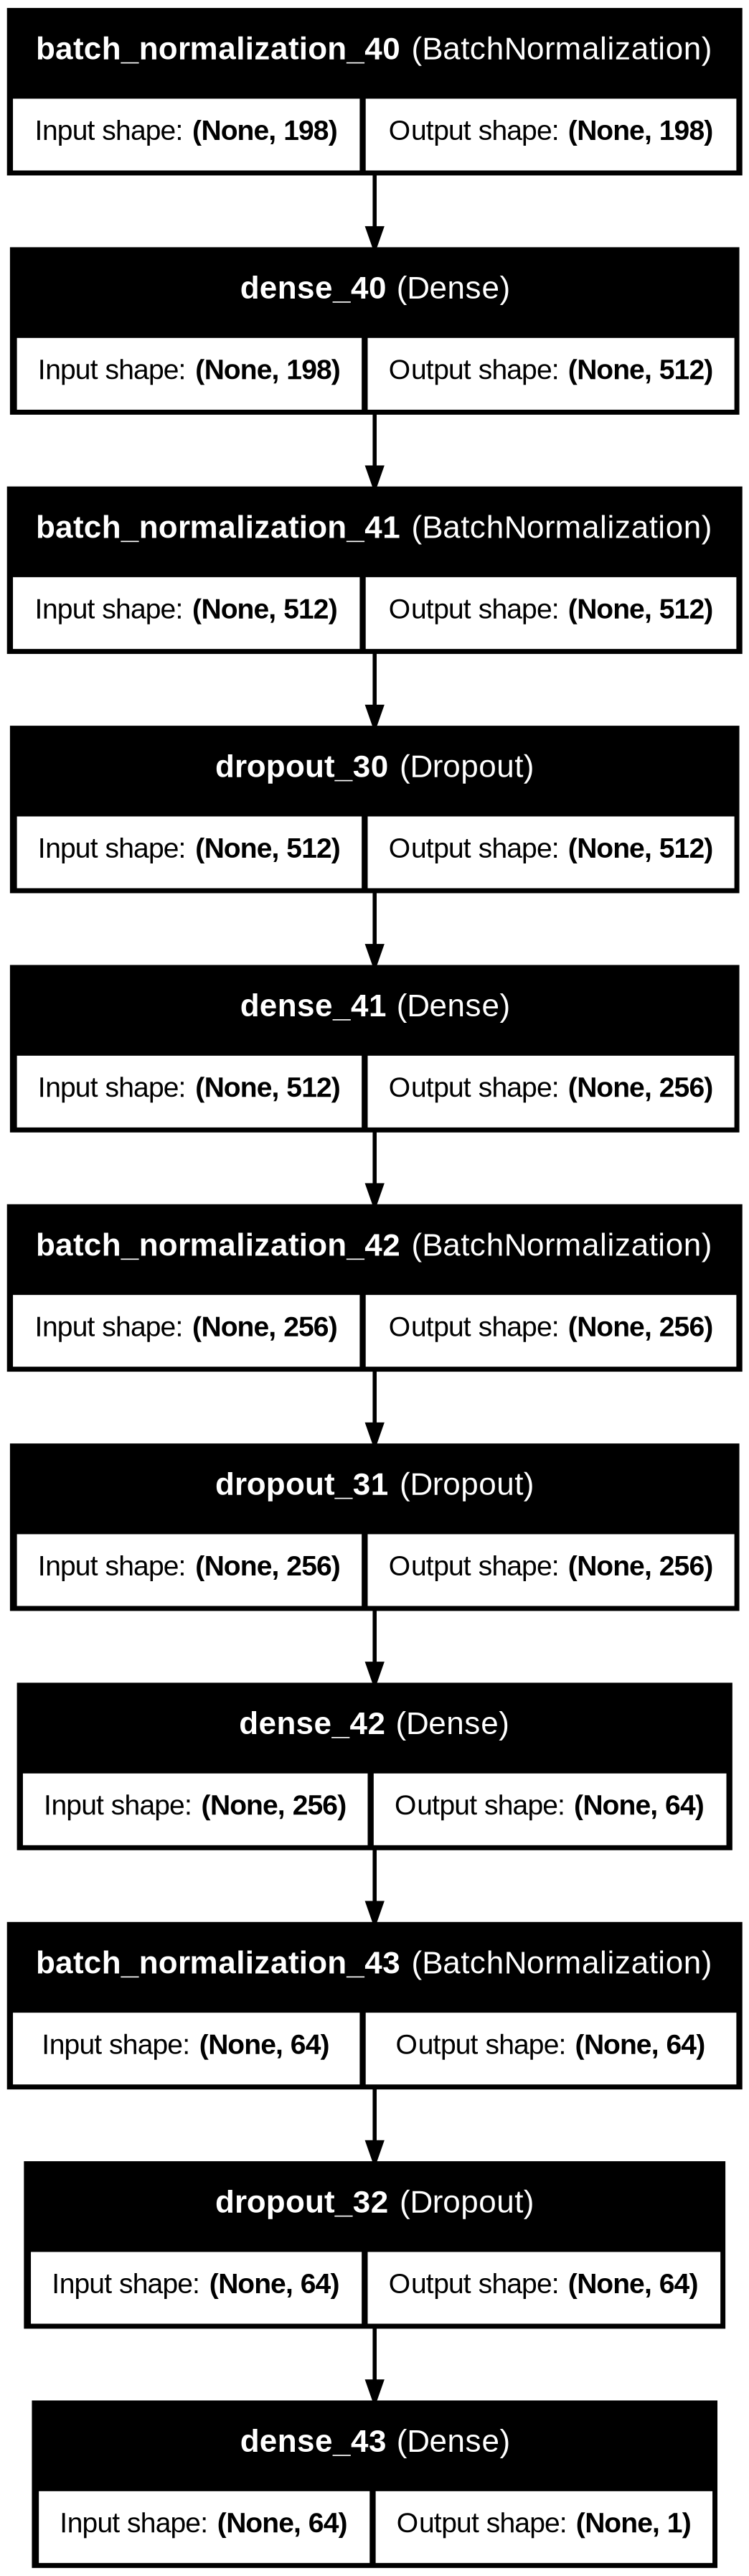

In [35]:
tf.keras.utils.plot_model(
    load_model,
    rankdir='TB',
    show_layer_names=True,
    show_shapes=True,
    expand_nested=True,
    # show_dtype=True,
)

# display(Image('/kaggle/working/model.png'))

In [36]:
def plot_results(history):
    for i in range(len(history)):
        loss_results = pd.DataFrame({'loss': history[i]['loss'], 'val_loss': history[i]['val_loss']})
        auc_results  = pd.DataFrame({'auc': history[i]['a_u_c'], 'val_auc': history[i]['val_auc']})
    
        plt.figure(figsize=(18, 6))
        marker = 'o'
    
        ## -- PLOT 1: LOSS --
        plt.subplot(121)
        sns.lineplot(loss_results, x=loss_results.index, y=loss_results['loss'], label='train', marker=marker)
        sns.lineplot(loss_results, x=loss_results.index, y=loss_results['val_loss'], label='valid', marker=marker)
        plt.title('LOSS', fontweight='semibold')
        plt.xlabel('epochs')
        plt.ylabel('auc')
    
        ## -- PLOT 2: ACCURACY --
        plt.subplot(122)
        sns.lineplot(auc_results, x=auc_results.index, y=auc_results['auc'], label='train', marker=marker)
        sns.lineplot(auc_results, x=auc_results.index, y=auc_results['val_auc'], label='valid', marker=marker)
        plt.title('AUC', fontweight='semibold')
        plt.xlabel('epochs')
        plt.ylabel('auc')

        stat_ = f"fold_score: {result['fold_score'][i]:.5f}"
        plt.scatter(x=0, y=0, label=stat_, color='y')
    
        plt.suptitle(f"- FOLD {i+1} -", fontsize=15, fontweight='semibold')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()
        print()

print('Plot function ready')

Plot function ready


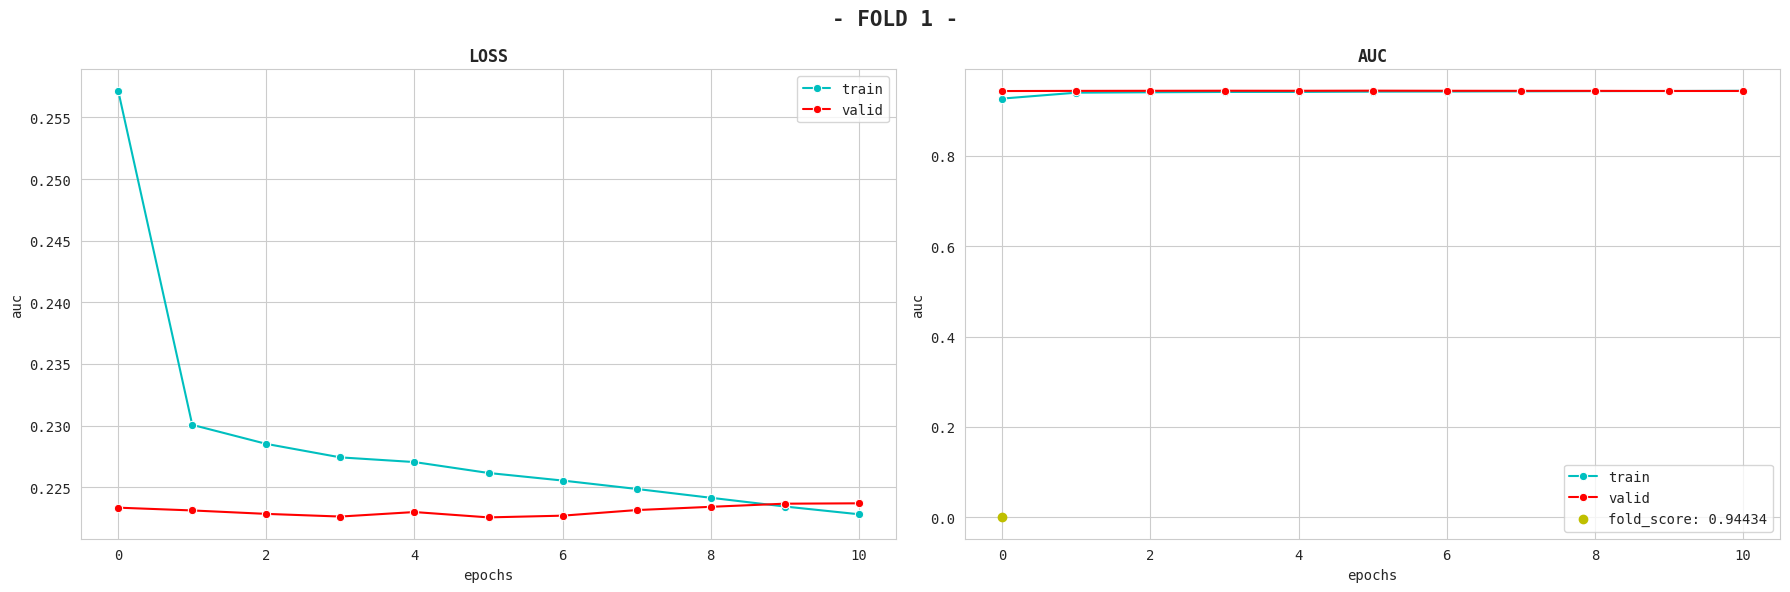

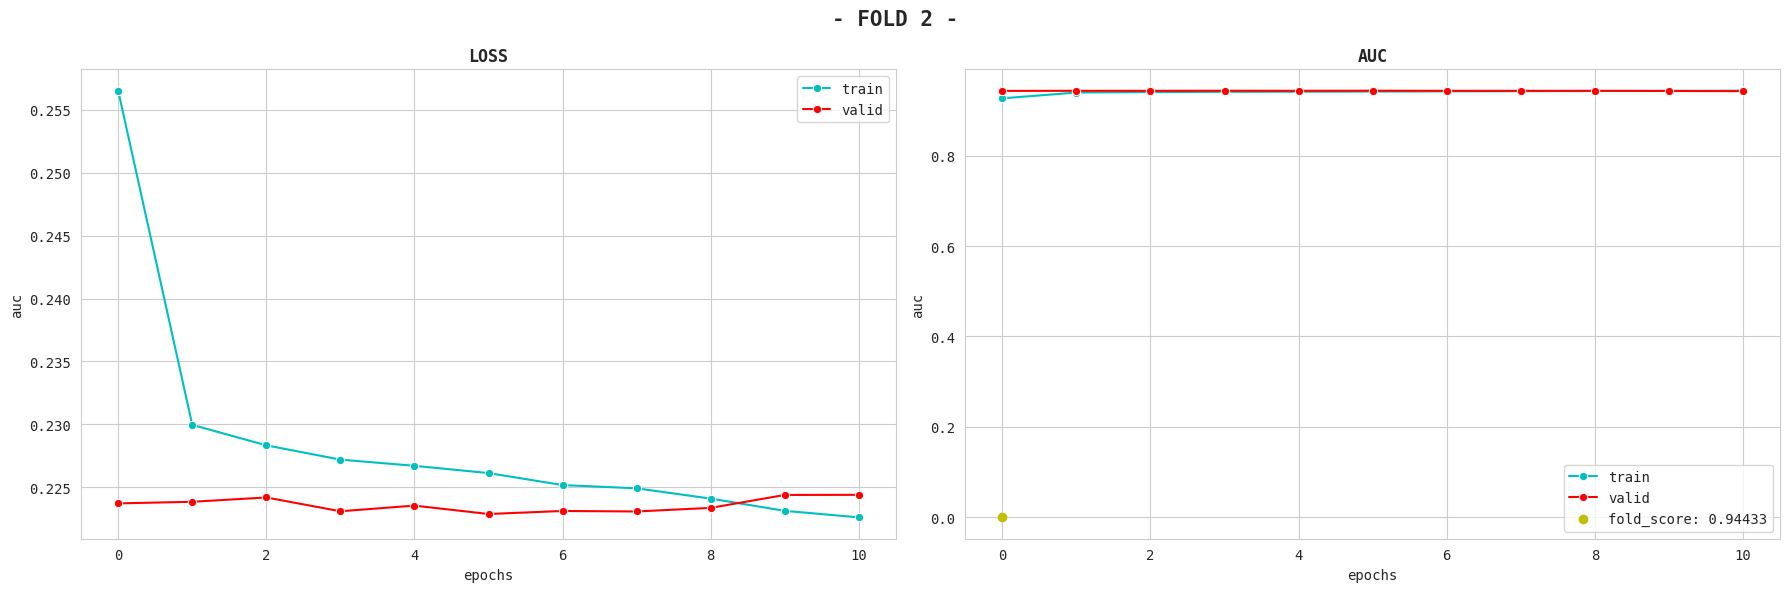

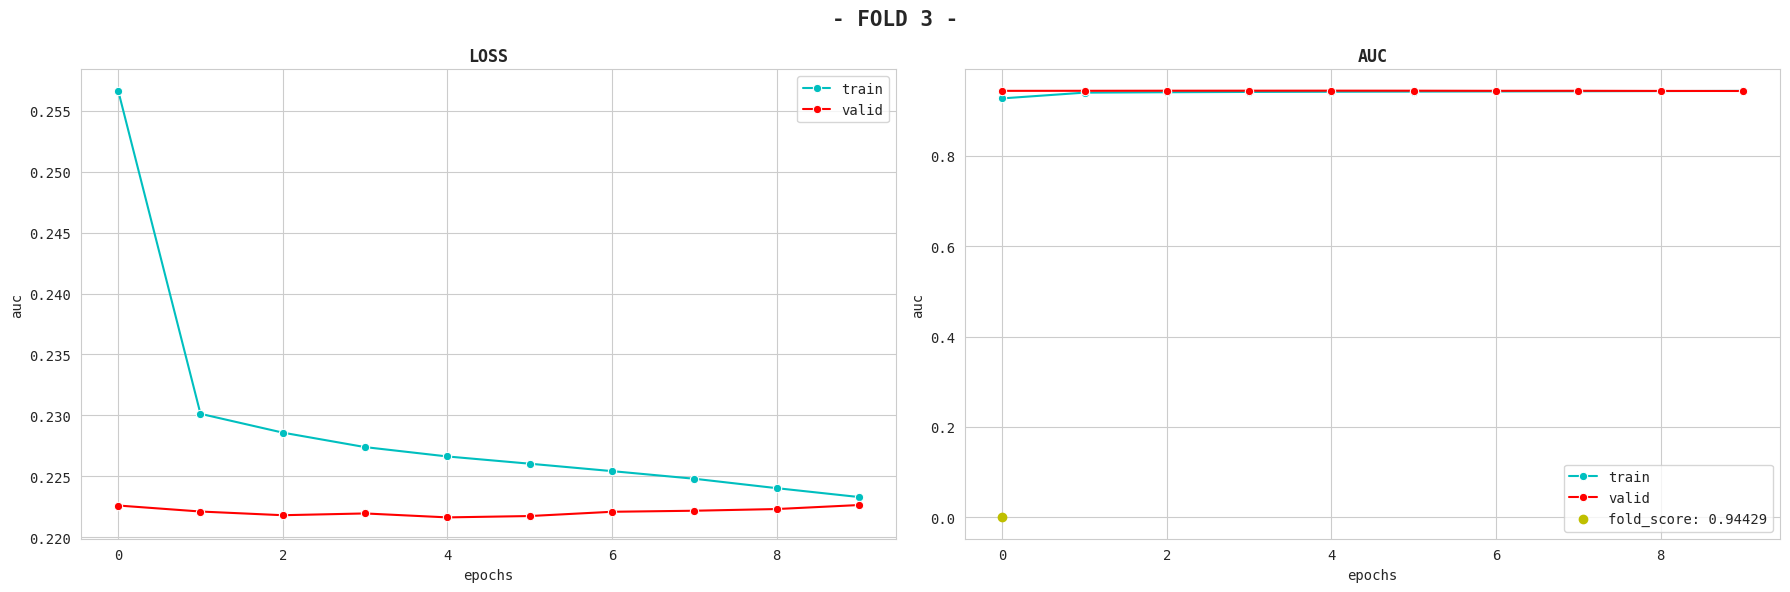

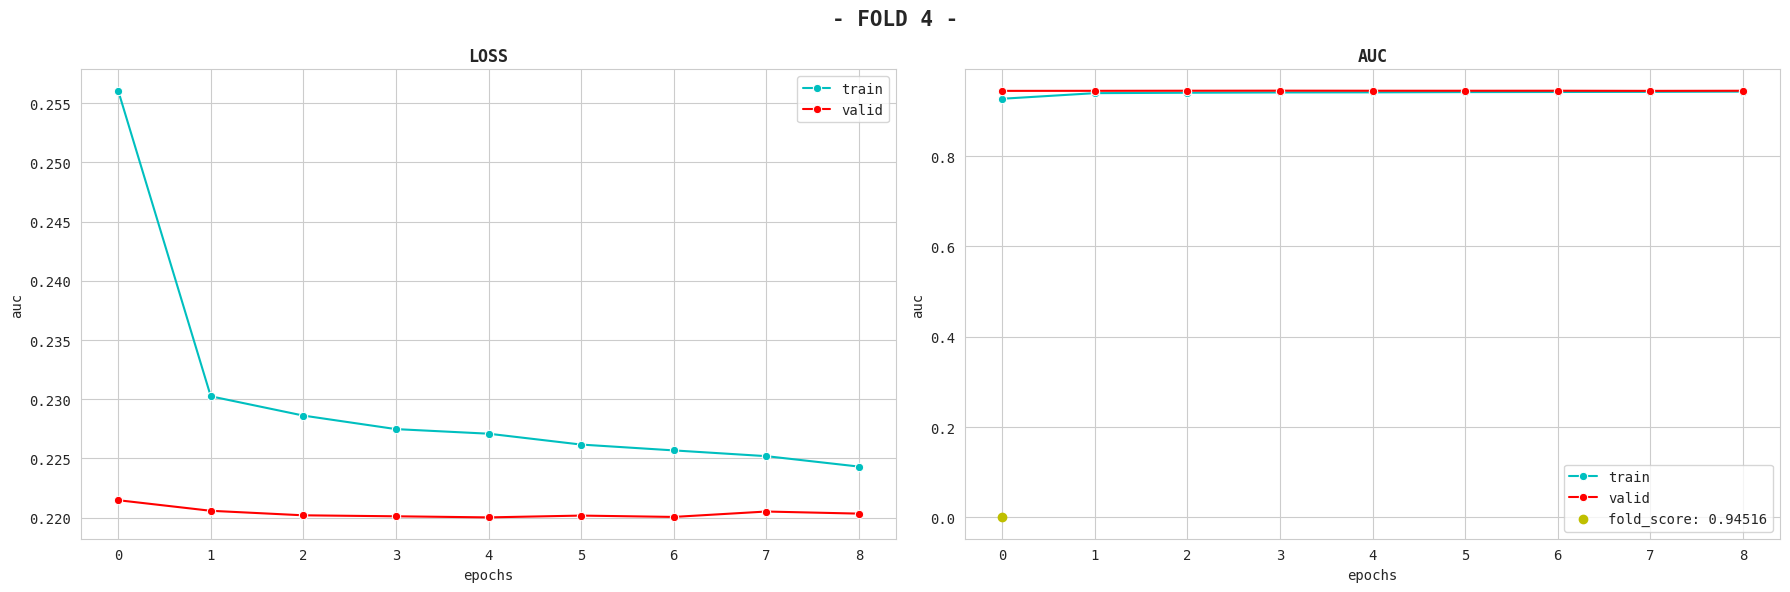

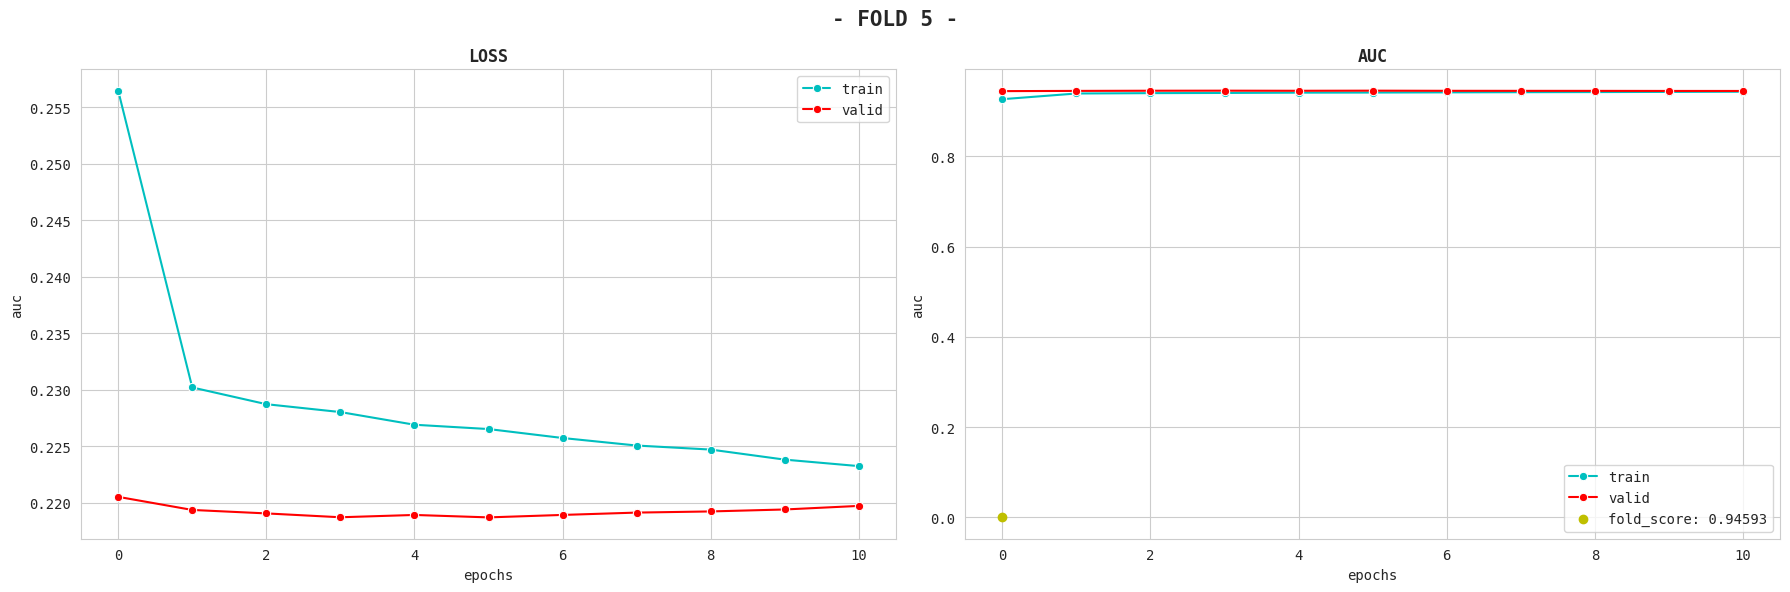

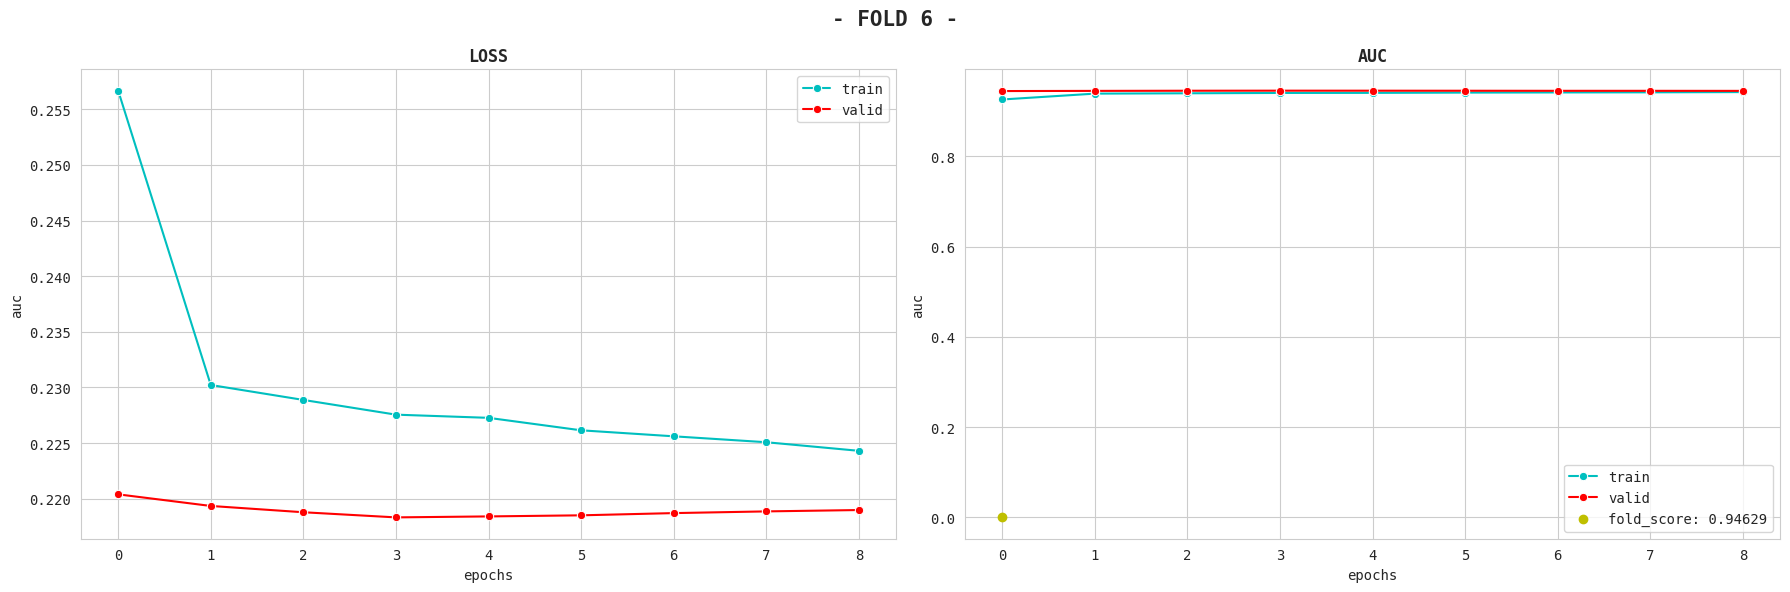

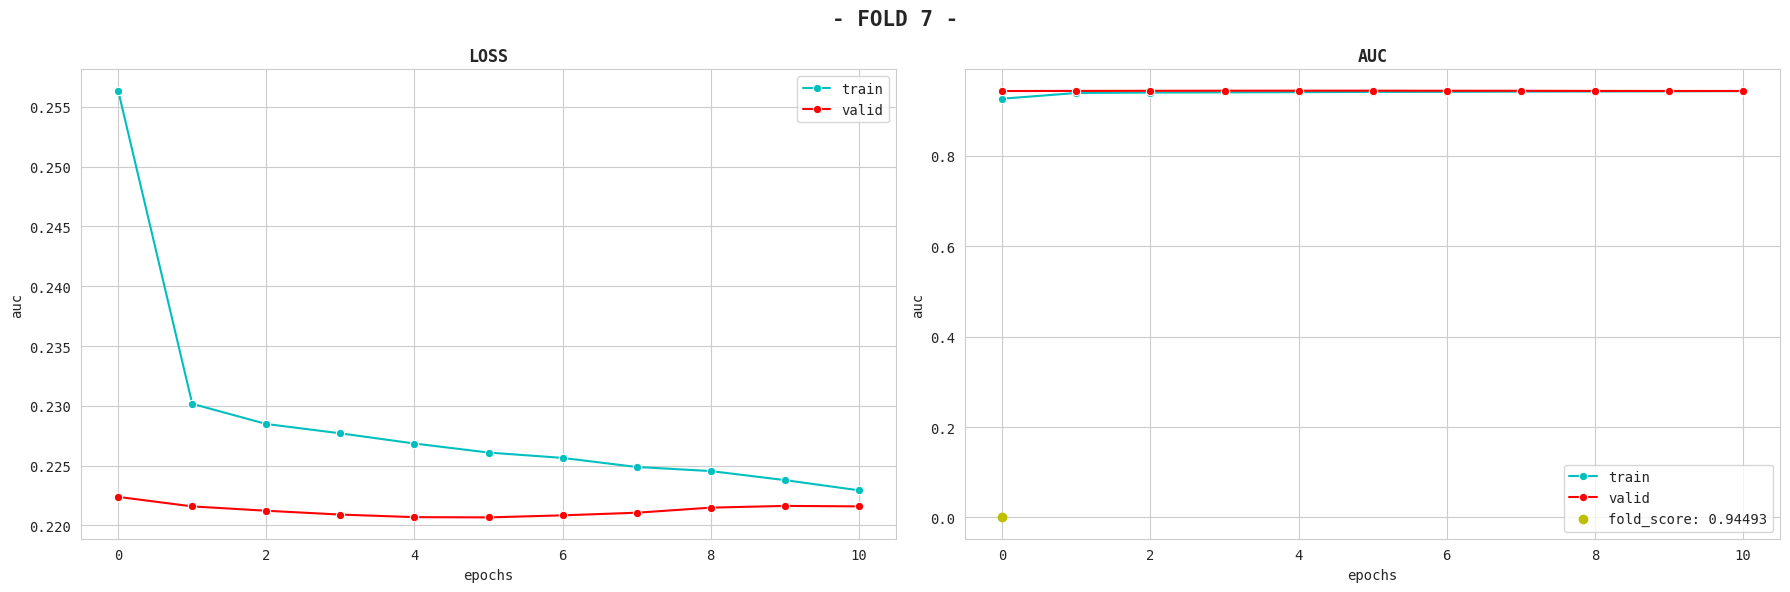

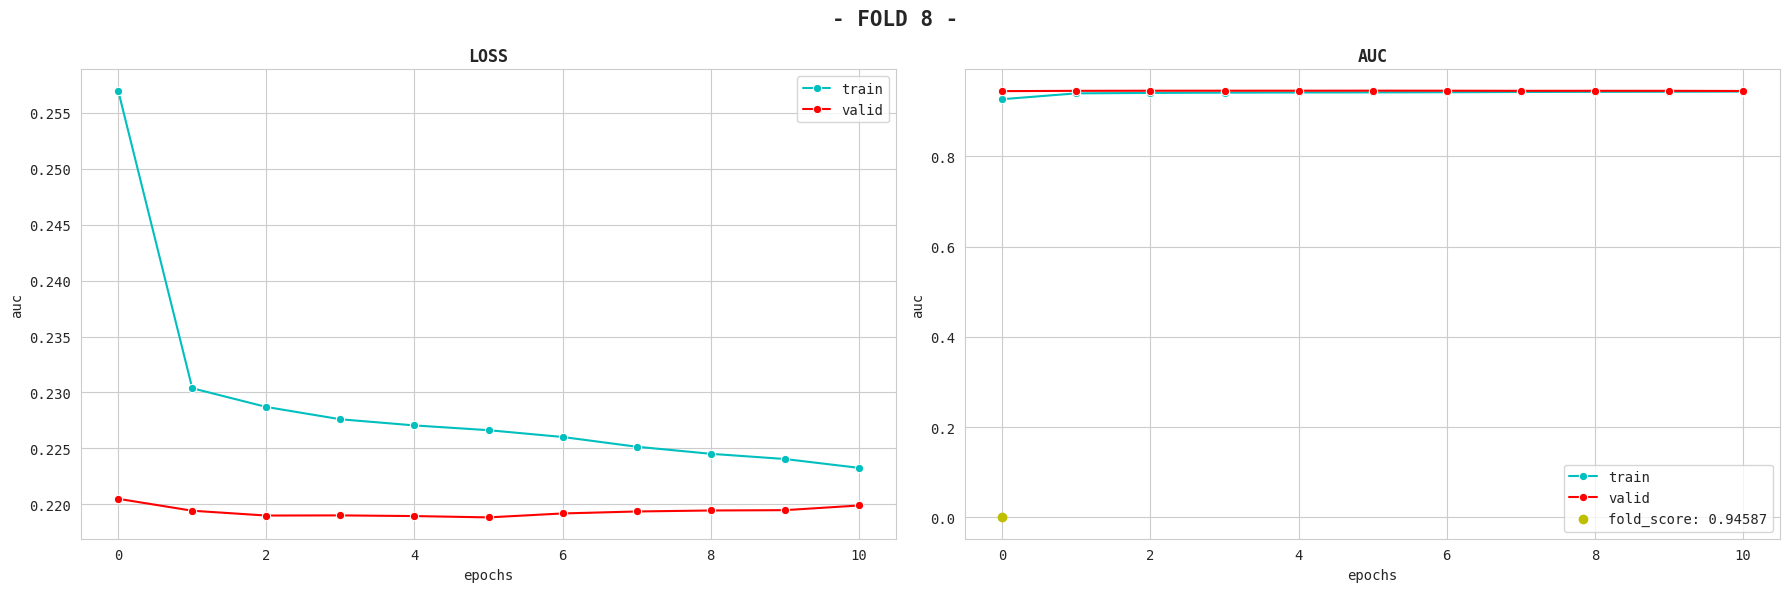

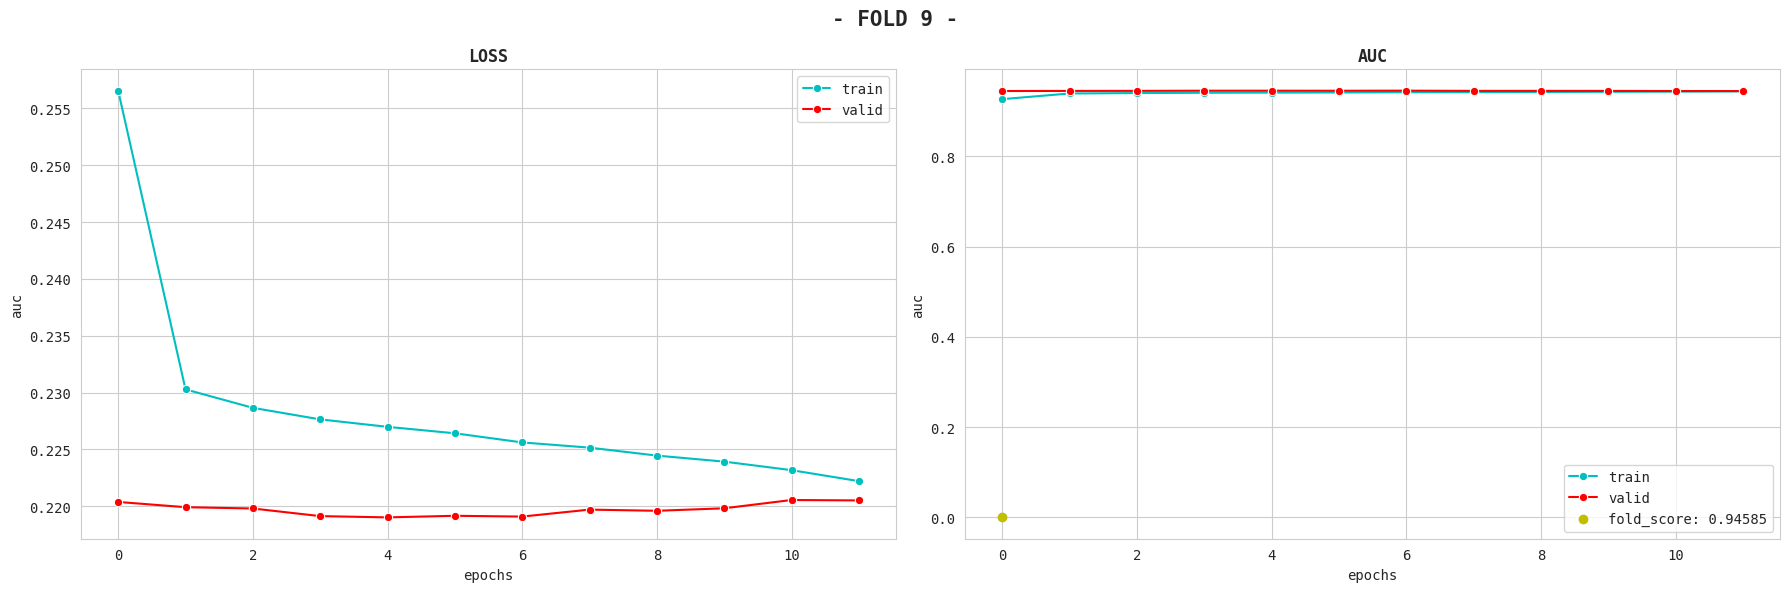

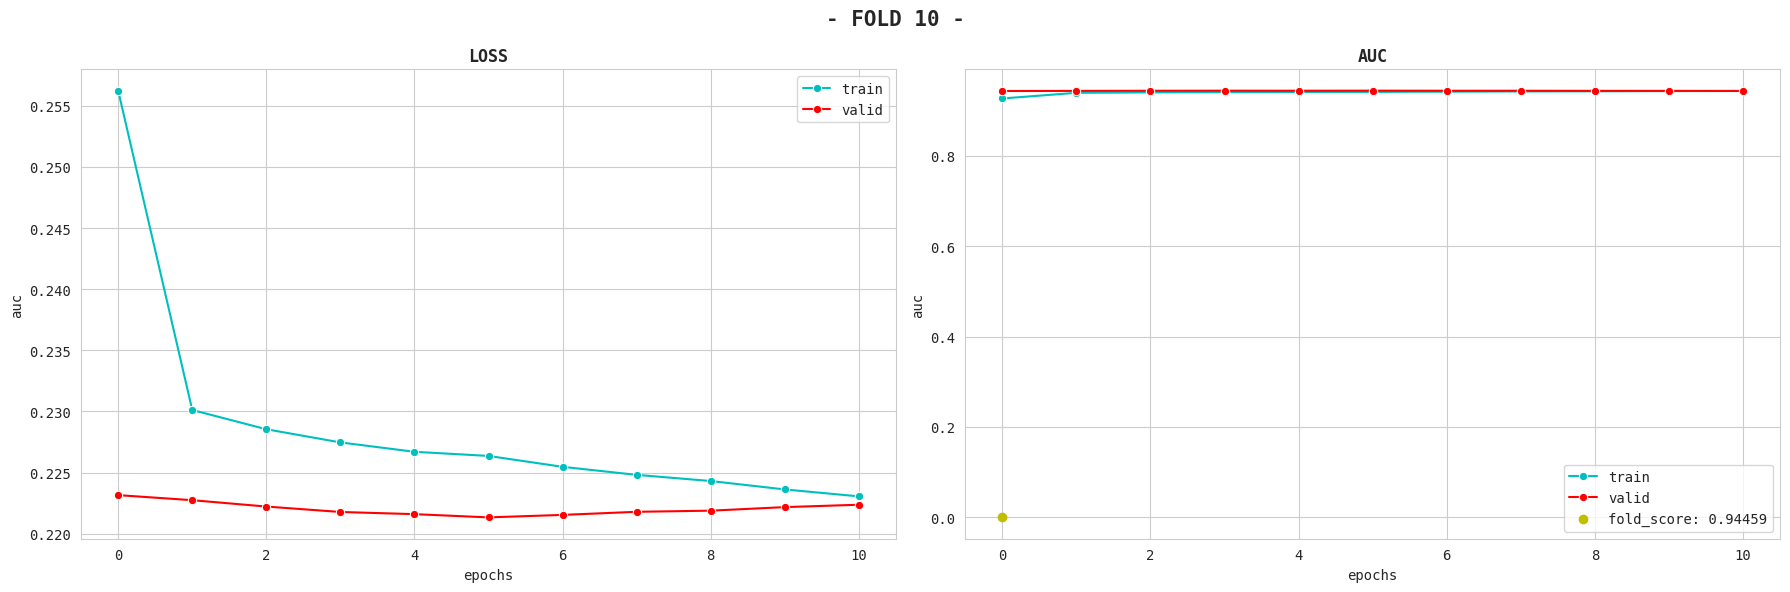

In [37]:
plot_results(result['history'])

💾 Submission -> 'submit_sciKeras114__945045.csv'



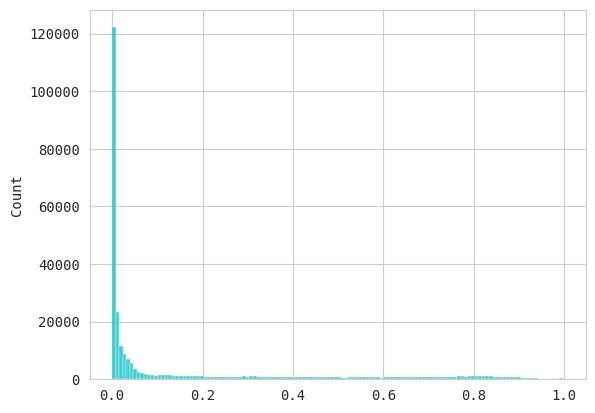

,id,Will_Buy_EV
0,668665,0.030213
1,668666,0.023715
2,668667,0.002127
3,668668,0.001336
4,668669,0.040068
...,...,...
286566,955231,0.000128
286567,955232,0.346147
286568,955233,0.000379
286569,955234,0.000257


In [38]:
n = f"{MODEL_}_{str(result['oof_score']).split('.')[1]}"

np.save(f"oof_{n}.npy", result["oof_preds"])
np.save(f"test_{n}.npy", result["test_preds"])

submission[TARGET] = result["test_preds"].ravel()
submission.to_csv(f"submit_{n}.csv", index=False)

print(f"💾 Submission -> 'submit_{n}.csv'\n")

sns.histplot(submission[TARGET].values)
plt.show()

submission

In [39]:
# ## -- PLOTTING RESULTS --
# histories = result['history']

# for i, data in tqdm(enumerate(histories), total=len(histories)):
#     loss_results = pd.DataFrame({'train_loss': data['loss'], 'val_loss': data['val_loss']})
#     auc_results = pd.DataFrame({'train_auc': data['auc'], 'val_auc': data['val_auc']})
#     plt.figure(figsize=(16, 5))
#     marker = 'o'

#     ## -- PLOT LOSS --
#     plt.subplot(121)
#     sns.lineplot(loss_results, x=loss_results.index, y=loss_results.train_loss, label='train_loss', marker=marker)
#     sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='val_loss', marker=marker)
#     plt.title('LOSS', fontweight='semibold')
#     plt.xlabel('Epochs')
#     plt.ylabel('Loss')

#     ## -- PLOT AUC --
#     plt.subplot(122)
#     sns.lineplot(auc_results, x=auc_results.index, y=auc_results.train_auc, label='train_auc', marker=marker)
#     sns.lineplot(auc_results, x=auc_results.index, y=auc_results.val_auc, label='val_auc', marker=marker)
#     plt.title('ROC-AUC', fontweight='semibold')
#     plt.xlabel('Epochs')
#     plt.ylabel('AUC')

#     stat_ = f"fold_auc: {result['fold_score'][i]:.5f}"
#     plt.scatter(x=0, y=0, label=stat_, color='y')

#     plt.suptitle(f"FOLD {i+1}", fontsize=16, fontweight='semibold')
#     plt.legend(loc='best')
#     plt.tight_layout()
#     plt.show()
#     print()